In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load data 
path = "/home/bnplab/projects/LAVA/recordings/2026-05-13_15-38-30_S999_export/enriched_eeg.csv"

eeg_data = pd.read_csv(path)

print(eeg_data.shape)

# select only relvant columns 
eeg_data = eeg_data[["time", "eeg_4", "eeg_20", "eeg_22", "eeg_24", "eeg_26"]]

# create laplacian
eeg_data["laplacian"] = eeg_data["eeg_4"] - (eeg_data["eeg_20"] + eeg_data["eeg_22"] + eeg_data["eeg_24"] + eeg_data["eeg_26"]) / 4

# demean 

eeg_data["laplacian"] = eeg_data["laplacian"] - eeg_data["laplacian"].mean()

eeg_data["ds_laplacian"] = eeg_data["laplacian"][::10]  # downsample by a factor of 10
eeg_data["ds_time"] = eeg_data["time"][::10]  # downsample time accordingly

ds_eeg_data = eeg_data[["ds_time", "ds_laplacian"]].dropna()  # drop NaN values that may arise from downsampling

(91994, 78)


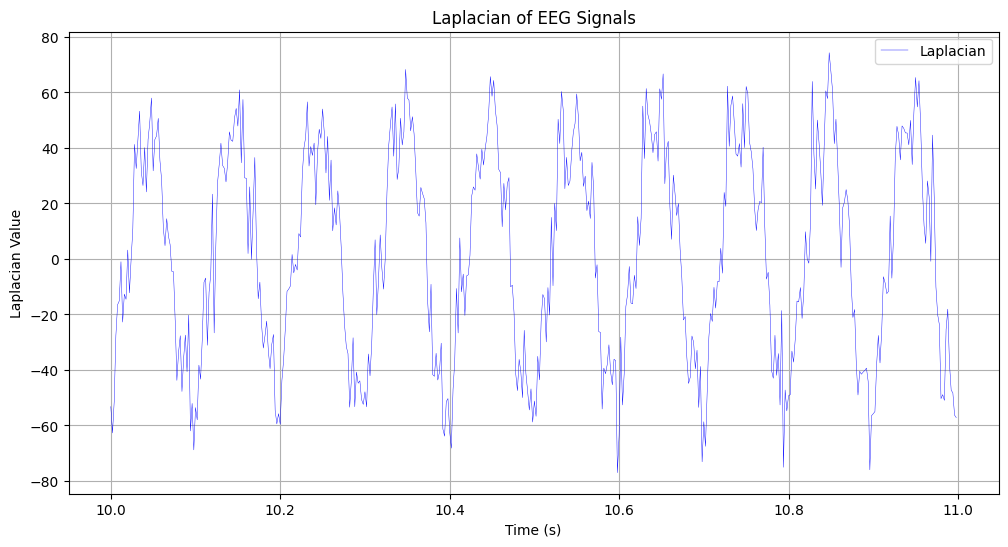

In [32]:
# plot the laplacian

range_to_plot = slice(5000, 5500)
plt.figure(figsize=(12, 6))
plt.plot(ds_eeg_data["ds_time"].iloc[range_to_plot], ds_eeg_data["ds_laplacian"].iloc[range_to_plot], label="Laplacian", color="blue", lw=0.3)
plt.xlabel("Time (s)")
plt.ylabel("Laplacian Value")
plt.title("Laplacian of EEG Signals")
plt.legend()
plt.grid()
plt.show()
